## Classical ML Model #1: **Binomial Logistic Regression**


First, we will import our pre-split and scaled training, validation, and test sets.

In [15]:
import pandas as pd
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training

### **Training Set**: Binomial Logistic Regression

We are trying to predict if the our target class URB is rural or urban, 2 classes so a Binomial Logistic Regression is a natural pick. Let's first create our model using the the import from the sklearn library for our logistic Regression

In [16]:
# Logistic Regression (L2 Regularization) - Training Phase
from sklearn.linear_model import LogisticRegression

# Regularized logistic regression model
logreg_model = LogisticRegression(
    penalty="l2",       # regularization type (this is default)
    C=1.0,               # regularization strength (also a default)
    solver="lbfgs",     # optimizer (good default for larger datasets)
    max_iter=100,
    random_state=42
)

logreg_model.fit(X_train_scaled, y_train)

# Training-set predictions and probabilities
y_train_pred = logreg_model.predict(X_train_scaled)
y_train_proba = logreg_model.predict_proba(X_train_scaled)[:, 1]

C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


With our training split, we currently have **28119** rows. We will use **44** features to predict target feature `URB` whether its rural or urban. But why 88 features? We performed one-hot-encoding on 7 of our used features. `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Furthurmore, we remove the target column `URB`.

In [17]:
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Training features used: {X_train_scaled.shape[1]}")

Training samples: 28119
Training features used: 88


Let's now output our metrics. It is important to note that our classes are imbalanced. The entire dataset contains 40171 total number of entries. There are 15373 urban families and 24798 rural families.

In [18]:
from MCO_functions import report_binary_metrics

train_report = report_binary_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    y_proba=y_train_proba,
    title="Training Metrics",
    n_iter=logreg_model.n_iter_,
)

cm_train = train_report["cm"]
cm_train_df = train_report["cm_df"]
rural_acc_train = train_report["rural_acc"]
urban_acc_train = train_report["urban_acc"]

Training Metrics (Overall)
Accuracy        : 0.8261
Balanced Acc    : 0.8028
ROC-AUC         : 0.8895
PR-AUC          : 0.8628
Log Loss        : 0.3902

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.9024,0.7031
Precision,0.8306,0.8171
Recall,0.9024,0.7031
F1-score,0.8650,0.7558



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)           15664            1694
Actual Urban (1)            3195            7566

Iterations used: [96]


Our model used 96 iterations in the training set, lets visualize a graph of its loss to see how it improves

C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\allen

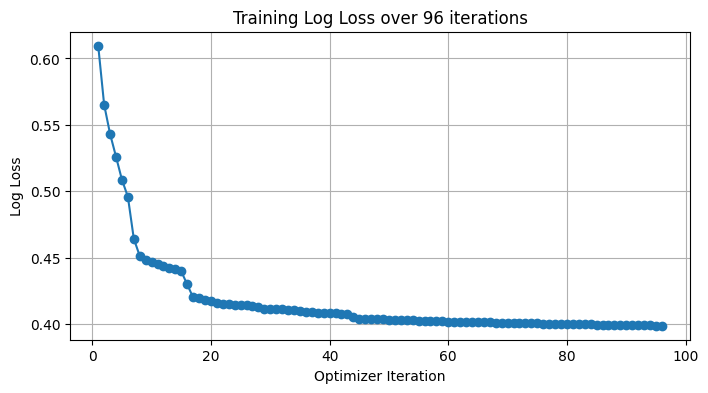

Showing first 10 and last 10 iterations out of 96 total:


,Optimizer Iteration,Train Log Loss
0,1,0.609578
1,2,0.565195
2,3,0.543191
3,4,0.526038
4,5,0.508636
5,6,0.495898
6,7,0.464254
7,8,0.451284
8,9,0.448489
9,10,0.446534


In [19]:
# Optional: inspect training loss over all optimizer iterations (reusable helper)
from MCO_functions import track_logreg_loss_by_iteration

# Track the same number of iterations used by the fitted training model
total_iters = int(np.ravel(logreg_model.n_iter_)[0])

loss_tracking = track_logreg_loss_by_iteration(
    X_train=X_train_scaled,
    y_train=y_train,
    total_iterations=total_iters,
    c=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight=None,
    random_state=42,
    head_n=10,
    tail_n=10,
    plot=True,
)

loss_history_df = loss_tracking["full_loss_df"]
loss_window_df = loss_tracking["compact_loss_df"]

print(f"Showing first 10 and last 10 iterations out of {total_iters} total:")
display(loss_window_df.style.format({"Train Log Loss": "{:.6f}"}))

# **[5]** Error Analysis and Model Tuning


### **Validation Set** (Pre-Tuned): Binomial Logistic Regression

Using our trained model, let's test it on the validation set. The validation set has **6026** rows of data

In [20]:
from MCO_functions import report_binary_metrics

# BEFORE TUNING: baseline validation metrics
y_val_pred = logreg_model.predict(X_val_scaled)
y_val_proba = logreg_model.predict_proba(X_val_scaled)[:, 1]

val_base_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    title="Current Validation Metrics (Before Tuning)",
)

cm_base = val_base_report["cm"]
cm_base_df = val_base_report["cm_df"]
rural_acc_base = val_base_report["rural_acc"]
urban_acc_base = val_base_report["urban_acc"]

Current Validation Metrics (Before Tuning) (Overall)
Accuracy        : 0.8140
Balanced Acc    : 0.7925
ROC-AUC         : 0.8793
PR-AUC          : 0.8498
Log Loss        : 0.4072

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8839,0.7012
Precision,0.8268,0.7892
Recall,0.8839,0.7012
F1-score,0.8544,0.7426



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3288             432
Actual Urban (1)             689            1617


Let's compare the model's performance with the training and validation set.

In [21]:
# Training vs Pre-Tuned Validation comparison with color highlights
metric_order = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map = {
    "Accuracy": "higher", "Balanced Acc": "higher", "Rural Accuracy": "higher",
    "Urban Accuracy": "higher", "ROC-AUC": "higher", "PR-AUC": "higher",
    "Log Loss": "lower",
}

comparison_df = pd.concat(
    [
        build_metric_series(y_train, y_train_pred, y_train_proba, cm_train, metric_order).rename("Training"),
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order).rename("Pre-Tuned Validation"),
    ],
    axis=1,
)
comparison_df["Val - Train"] = comparison_df["Pre-Tuned Validation"] - comparison_df["Training"]

styled_comparison = (
    comparison_df.style
    .format(
        {
            "Training": "{:.4f}",
            "Pre-Tuned Validation": "{:.4f}",
            "Val - Train": "{:+.4f}",
        }
    )
    .apply(lambda row: highlight_val_train_row(row, direction_map, delta_col="Val - Train"), axis=1)
    .set_caption(
        "Training vs Pre-Tuned Validation Metrics "
        "(Val - Train color: green = better on validation given metric direction, red = worse, yellow = tie)"
    )
)

#### Validation set vs Training set

The behaviour is expected. Since the model still hasn't seen the validation set, a lower overall perfomance is expected.

In [22]:
print("Training vs Pre-Tuned Validation")
print("Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change")
display(styled_comparison)

Training vs Pre-Tuned Validation
Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change


,Training,Pre-Tuned Validation,Val - Train
Accuracy,0.8261,0.8140,-0.0122
Balanced Acc,0.8028,0.7925,-0.0102
Rural Accuracy,0.9024,0.8839,-0.0185
Urban Accuracy,0.7031,0.7012,-0.0019
ROC-AUC,0.8895,0.8793,-0.0102
PR-AUC,0.8628,0.8498,-0.0130
Log Loss,0.3902,0.4072,+0.0171


With that in mind, let's **fine-tune** our model

We will create a list of values per hyperparameters located in `run_logreg_validation_grid` function. The function iterates through the possible combinations/configurations of hyperparameters and chooses the best set of hyperparameters

We base our decision of the best (highest) `balanced accuracy` because of our high class imbalance, **38% Urban** and **61% Rural**.

### **Validation Set** (Tuned): Biomial Logistic Regression 

In [23]:
# Fine tuning our model with validation set
candidate_df = run_logreg_validation_grid(X_train_scaled, y_train, X_val_scaled, y_val)

print("\nValidation Tuning Results (top 5):")
display(candidate_df.head(5))

best = candidate_df.iloc[0]
best_c = float(best["C"])
best_solver = str(best["Solver"])
best_threshold = float(best["Threshold"])

if best["Class_Weight"] == "None":
    best_class_weight = None
elif best["Class_Weight"] == "balanced":
    best_class_weight = "balanced"
else:
    best_class_weight = ast.literal_eval(best["Class_Weight"])

print("\nBest validation configuration (Balanced):")
print(f"C            : {best_c}")
print(f"Solver       : {best_solver}")
print(f"Class Weight : {best_class_weight}")
print(f"Threshold    : {best_threshold}")

# Fit tuned model selected from validation ranking
logreg_model_tuned = LogisticRegression(
    penalty="l2",
    C=best_c,
    solver=best_solver,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)
logreg_model_tuned.fit(X_train_scaled, y_train)

y_val_proba_tuned = logreg_model_tuned.predict_proba(X_val_scaled)[:, 1]
y_val_pred_tuned = (y_val_proba_tuned >= best_threshold).astype(int)

C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\allen


Validation Tuning Results (top 5):


,C,Solver,Class_Weight,Threshold,Accuracy,Balanced_Acc,Rural_Acc,Urban_Acc,Rural_Precision,Rural_Recall,Rural_F1,Urban_Precision,Urban_Recall,Urban_F1,ROC_AUC,PR_AUC,LogLoss
0,3.0,lbfgs,"{0: 1.1, 1: 1.0}",0.35,0.806505,0.802401,0.819892,0.784909,0.860124,0.819892,0.839527,0.729839,0.784909,0.756373,0.879236,0.849980,0.407386
1,30.0,liblinear,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802297,0.818817,0.785776,0.860452,0.818817,0.839118,0.728882,0.785776,0.756260,0.879077,0.850060,0.408014
2,3.0,lbfgs,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879138,0.849959,0.407948
3,3.0,lbfgs,"{0: 1.2, 1: 1.0}",0.33,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879132,0.850031,0.408624
4,10.0,lbfgs,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879101,0.849978,0.408025



Best validation configuration (Balanced):
C            : 3.0
Solver       : lbfgs
Class Weight : {0: 1.1, 1: 1.0}
Threshold    : 0.35


C:\Users\allen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [24]:
from MCO_functions import report_binary_metrics

val_tuned_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred_tuned,
    y_proba=y_val_proba_tuned,
    title="Tuned Model Validation Metrics",
    threshold=best_threshold,
    n_iter=logreg_model_tuned.n_iter_,
)

cm_tuned = val_tuned_report["cm"]
cm_tuned_df = val_tuned_report["cm_df"]
rural_acc_tuned = val_tuned_report["rural_acc"]
urban_acc_tuned = val_tuned_report["urban_acc"]



Tuned Model Validation Metrics (Overall)
Threshold used  : 0.35
Accuracy        : 0.8065
Balanced Acc    : 0.8024
ROC-AUC         : 0.8792
PR-AUC          : 0.8500
Log Loss        : 0.4074

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8199,0.7849
Precision,0.8601,0.7298
Recall,0.8199,0.7849
F1-score,0.8395,0.7564



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3050             670
Actual Urban (1)             496            1810

Iterations used: [92]


What hyperparameters changed during tuning?

In [25]:
print("\nWhat changed during tuning?")
print(f"- C: 1.0 -> {best_c}")
print(f"- Solver: lbfgs -> {best_solver}")
print(f"- Class weight: None -> {best_class_weight}")
print(f"- Decision threshold: 0.50 -> {best_threshold}")


What changed during tuning?
- C: 1.0 -> 3.0
- Solver: lbfgs -> lbfgs
- Class weight: None -> {0: 1.1, 1: 1.0}
- Decision threshold: 0.50 -> 0.35


Now let's check if the model's performance post-tuning improved againts pre-tuning

In [26]:
# Pre-tuned vs Post-tuned validation comparison (same style as earlier comparison table)
metric_order_tuning = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_tuning = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

tuned_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order_tuning).rename("Pre-Tuned Validation"),
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_tuning).rename("Post-Tuned Validation"),
    ],
    axis=1,
)
tuned_comparison_df["Post - Pre"] = (
    tuned_comparison_df["Post-Tuned Validation"] - tuned_comparison_df["Pre-Tuned Validation"]
)

styled_tuned_comparison = (
    tuned_comparison_df.style
    .format(
        {
            "Pre-Tuned Validation": "{:.4f}",
            "Post-Tuned Validation": "{:.4f}",
            "Post - Pre": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_tuning, delta_col="Post - Pre"),
        axis=1,
    )
    .set_caption(
        "Pre-Tuned vs Post-Tuned Validation Metrics "
        "(Post - Pre color: green = improved after tuning given metric direction, red = worse, yellow = tie)"
    )
)

print("Pre-Tuned vs Post-Tuned Validation")
print("Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change")
display(styled_tuned_comparison)

Pre-Tuned vs Post-Tuned Validation
Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change


,Pre-Tuned Validation,Post-Tuned Validation,Post - Pre
Accuracy,0.8140,0.8065,-0.0075
Balanced Acc,0.7925,0.8024,+0.0099
Rural Accuracy,0.8839,0.8199,-0.0640
Urban Accuracy,0.7012,0.7849,+0.0837
ROC-AUC,0.8793,0.8792,-0.0001
PR-AUC,0.8498,0.8500,+0.0002
Log Loss,0.4072,0.4074,+0.0001


# **[6]** Model Evaluation


### **Test Set**: Binomial Logistic Regression

The test split also contains **6026** entries of data.

In [27]:
from MCO_functions import report_binary_metrics

# Final Test-Set Evaluation (locked model from validation tuning)
# Use tuned model and tuned decision threshold selected on validation set
y_test_proba = logreg_model_tuned.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_report = report_binary_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    title="Final Test Metrics",
    threshold=best_threshold,
)

cm_test = test_report["cm"]
cm_test_df = test_report["cm_df"]
rural_acc_test = test_report["rural_acc"]
urban_acc_test = test_report["urban_acc"]

Final Test Metrics (Overall)
Threshold used  : 0.35
Accuracy        : 0.8050
Balanced Acc    : 0.7998
ROC-AUC         : 0.8852
PR-AUC          : 0.8575
Log Loss        : 0.3975

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8220,0.7775
Precision,0.8563,0.7303
Recall,0.8220,0.7775
F1-score,0.8388,0.7532



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3058             662
Actual Urban (1)             513            1793


Now let's compare the model's performance on the test and post-tuning sets

In [28]:
# Post-tuned validation vs Test-set comparison (same style as earlier comparison table)
metric_order_test = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_test = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

test_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_test).rename("Post-Tuned Validation"),
        build_metric_series(y_test, y_test_pred, y_test_proba, cm_test, metric_order_test).rename("Test Set"),
    ],
    axis=1,
)
test_comparison_df["Test - Post"] = (
    test_comparison_df["Test Set"] - test_comparison_df["Post-Tuned Validation"]
)

styled_test_comparison = (
    test_comparison_df.style
    .format(
        {
            "Post-Tuned Validation": "{:.4f}",
            "Test Set": "{:.4f}",
            "Test - Post": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_test, delta_col="Test - Post"),
        axis=1,
    )
    .set_caption(
        "Post-Tuned Validation vs Test-Set Metrics "
        "(Test - Post color: green = improved on test given metric direction, red = worse, yellow = tie)"
    )
)

print("Post-Tuned Validation vs Test Set")
print("Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change")
display(styled_test_comparison)

Post-Tuned Validation vs Test Set
Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change


,Post-Tuned Validation,Test Set,Test - Post
Accuracy,0.8065,0.8050,-0.0015
Balanced Acc,0.8024,0.7998,-0.0026
Rural Accuracy,0.8199,0.8220,+0.0022
Urban Accuracy,0.7849,0.7775,-0.0074
ROC-AUC,0.8792,0.8852,+0.0060
PR-AUC,0.8500,0.8575,+0.0075
Log Loss,0.4074,0.3975,-0.0099


<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text